This page aims to reproduce the Numerical Experiment from Section 4 of Margossian et al. Some of the plotting code is from analyze_results.ipynb

In [1]:
!pip install -Uq tfp-nightly[jax]
!pip install inference_gym
!pip install tf-nightly

# remember to restart runtime after changing the environment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 74.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 390.9/390.9 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 625.0/625.0 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 127.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 85.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 28.4 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requi

In [1]:
import numpy as np
# from matplotlib.pyplot import *

import os
# in case jax eats up my GPU RAM
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

import jax
from jax import random
from jax import numpy as jnp

# from inference_gym import using_jax as gym

from tensorflow_probability.substrates import jax as tfp
tfd = tfp.distributions
from inference_gym import using_jax as gym
tfb = tfp.bijectors

from tensorflow_probability.substrates import numpy as tfp_np
tfd_np = tfp_np.distributions

import matplotlib.pyplot as plt

import pandas as pd

import gc

# check if this is run on a gpu
print(jax.devices())
print(jax.default_backend())

import warnings
warnings.filterwarnings('ignore')

import psutil

process = psutil.Process(os.getpid())

def mem(msg):
    print(f"{msg}: {process.memory_info().rss / 1024**2:.1f} MB")

[CudaDevice(id=0)]
gpu


below is tying to replicate section 4.2:  
results when running 2048 chains with K =16 superchains, M = 128 subchains per superchains, after warmup, we do N=1 sample. For every model we repeat the experiment 10 times. each time we use different seed and run the experiements, we need to keep all 10 results, plot the avg MSE, best run and the worst run.  
The warmup window are:[  10   20   30   40   50   60   70   80   90  100  200  300  400  500
  600  700  800  900 1000]



Set up the problem, so far we dont change the number of superchain/subchains:

In [2]:
max_warmup = 1000
warmup_window = 100

window_array = np.append(np.repeat(10, 10),
                      np.repeat(warmup_window, max_warmup // warmup_window - 1))

warmup_length = np.repeat(10, len(window_array))
for i in range(len(warmup_length) - 1):
    warmup_length[i + 1] = warmup_length[i] + window_array[i + 1]

print(warmup_length)

[  10   20   30   40   50   60   70   80   90  100  200  300  400  500
  600  700  800  900 1000]


In [3]:
# kernel setup:
target = gym.targets.VectorModel(gym.targets.Banana(),
                                    flatten_sample_transformations=True)
num_dimensions = target.event_shape[0]
init_step_size = 1.

def target_log_prob_fn(x):
  """Unnormalized, unconstrained target density.

  This is a thin wrapper that applies the default bijectors so that we can
  ignore any constraints.
  """
  y = target.default_event_space_bijector(x)
  fldj = target.default_event_space_bijector.forward_log_det_jacobian(x)
  return target.unnormalized_log_prob(y) + fldj


offset = 2
def initialize (shape, key = random.PRNGKey(37272709)):
    return 3 * random.normal(key, shape + (num_dimensions,)) + offset

# Transition kernel for short regime
repitition = 10
num_chains_short = 2048
num_super_chains = 16

def kernel_setup(warmup_length, naive):
  num_warmup_short, num_sampling_short = warmup_length, 1
  total_samples_short = num_warmup_short + num_sampling_short

  kernel_short = tfp.mcmc.HamiltonianMonteCarlo(target_log_prob_fn, init_step_size, 1)
  kernel_short = tfp.experimental.mcmc.GradientBasedTrajectoryLengthAdaptation(kernel_short, num_warmup_short)
  kernel_short = tfp.mcmc.DualAveragingStepSizeAdaptation(
      kernel_short, num_warmup_short, target_accept_prob = 0.75,  #0.75,
      reduce_fn = tfp.math.reduce_log_harmonic_mean_exp)

  initial_state = initialize((num_dimensions,))

  if (naive):
    # initialize each chain at a different location, could it be the naive way?
    initial_state = initialize((num_chains_short,))

  else:
    # Chains within a super chain are all initialized at the same location
    # Here we use the same initial points as in the long regime.
    initial_state = initial_state  # initialize((num_super_chains,))
    initial_state = np.repeat(initial_state, num_chains_short // num_super_chains,
                            axis = 0)
  return kernel_short, initial_state, total_samples_short

def _reduce_variance_interval(x, axis=None, biased=True, keepdims=False):
    # ddof=0 is biased variance (N), ddof=1 is unbiased variance (N-1)
    ddof = 0 if biased else 1
    return jnp.var(x, axis=axis, ddof=ddof, keepdims=keepdims)


def nested_rhat_constrained(result_state, num_super_chains,idx):
    # since we use only N=1, W_k is reduced to 0

    num_sub_chains = result_state.shape[0] // num_super_chains
    num_dimensions = result_state.shape[1]

    chain_states = result_state.reshape(1, -1, num_sub_chains, num_dimensions)
    # chain_states.shape = (1,16,128,2)
    # f_bar 1*k is:
    mean_subchain = jnp.mean(chain_states, axis=2)
    # mean_subchain.shape =(1,16,2)

    # f_bar **K is:
    mean_superchain = jnp.mean(mean_subchain, axis=1)
    # mean_superchain.shape = (1,2)

    variance_chain = _reduce_variance_interval(chain_states, axis=2, biased=False)
    # print(variance_chain.shape) # (1,16,2)
    W = jnp.mean(variance_chain, axis=1)
    # print(f"W dim: {W.shape}") # (1,2)
    B = _reduce_variance_interval(mean_subchain, axis=1, biased=False) # variance of between super chain

    r_hat = jnp.sqrt(1+B/W)[:,idx]
    return r_hat

In [11]:
r_hat_lists = [[] for _ in range(num_dimensions)]
for sim in range(10):
  for dim in range(num_dimensions):
        r_hat_lists[dim].append(f"{sim}-th iteration, {dim}-th variable value")

r_hat_lists = np.array(r_hat_lists)
# print(r_hat_lists)
print(r_hat_lists[0])

['0-th iteration, 0-th variable value'
 '1-th iteration, 0-th variable value'
 '2-th iteration, 0-th variable value'
 '3-th iteration, 0-th variable value'
 '4-th iteration, 0-th variable value'
 '5-th iteration, 0-th variable value'
 '6-th iteration, 0-th variable value'
 '7-th iteration, 0-th variable value'
 '8-th iteration, 0-th variable value'
 '9-th iteration, 0-th variable value']


In [54]:
def simulation(keys,length, naive, repitition, MSE_list, R_Hat_list, num_dim):
  kernel_short, initial_state, total_samples_short = kernel_setup(length,naive)
  result_mse = []
  for sim in range(repitition):
    result_short = tfp.mcmc.sample_chain(
        total_samples_short, initial_state, kernel = kernel_short,
        seed =keys[sim], trace_fn=None)[-1,:,:]

    estimate = result_short.mean(axis=0)
    error = estimate - mean_est
    se = error**2
    mse = se.mean()
    result_mse.append(mse)

    record = {
        "Warmup Length": length,
        "MSE":mse,
    }

    for dim in range(num_dim):
      new_r_hat = nested_rhat_constrained(result_short, num_super_chains, dim)
      record[f"r_hat_{dim}"] = new_r_hat[-1]
    R_Hat_list.append(record)
    del record
    del result_short
    gc.collect()

  # calculation time:
  result_mse = np.array(result_mse)
  result_mse_best = result_mse.min(axis=0)
  result_mse_worst = result_mse.max(axis=0)
  estimate_mse = result_mse.mean(axis=0)

  MSE_list.append({"Warmup Length":length,
                   "Avg MSE": estimate_mse,
                   "Best MSE": result_mse_best,
                   "Worst MSE": result_mse_worst})


  print(f"Warmup Length: {length}; mean of MSE is: {estimate_mse}")
  del kernel_short
  del initial_state
  del total_samples_short
  del result_mse
  gc.collect()

In [48]:
# Get some estimates of the mean and variance.
try:
  mean_est = target.sample_transformations['identity'].ground_truth_mean
except:
  print('no ground truth mean')
  mean_est = (result.all_states[num_warmup:, :]).mean(0).mean(0)
try:
  var_est = target.sample_transformations['identity'].ground_truth_standard_deviation**2
except:
  print('no ground truth std dev')
  var_est = ((result.all_states[num_warmup:, :]**2).mean(0).mean(0) -
             mean_est**2)

In [55]:
base_key = random.PRNGKey(0)
keys = random.split(base_key, repitition)
simulation_constriained_list = []
dot_plot_list = []

for length in [10, 20, 30]:
  simulation(
            keys,
            length,
            naive=False,
            repitition=repitition,
            MSE_list=simulation_constriained_list,
            R_Hat_list=dot_plot_list,
            num_dim=num_dimensions
        )

test_df_2 = pd.DataFrame(dot_plot_list)
test_df = pd.DataFrame(simulation_constriained_list)




Warmup Length: 10; mean of MSE is: 5.894411087036133
Warmup Length: 20; mean of MSE is: 4.819632053375244
Warmup Length: 30; mean of MSE is: 3.417165756225586


In [56]:
test_df.head()

,Warmup Length,Avg MSE,Best MSE,Worst MSE
0,10,5.894411,5.438864,6.449607
1,20,4.819632,3.822550,5.567114
2,30,3.417166,2.432395,4.889427


<Axes: title={'center': 'Rosenbrock'}, xlabel='Warmup Length'>

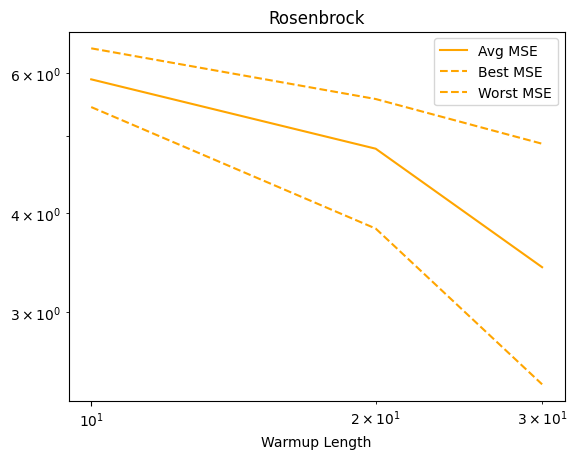

In [57]:
ax = test_df.plot(
    x="Warmup Length",
    y="Avg MSE",
    logx=True,
    logy=True,
    title="Rosenbrock",
    linestyle="-",
    color="orange"
)

test_df.plot(
    x="Warmup Length",
    y="Best MSE",
    logx=True,
    logy=True,
    linestyle="--",
    color="orange",
    ax=ax,
)
test_df.plot(
    x="Warmup Length",
    y="Worst MSE",
    logx=True,
    logy=True,
    linestyle="--",
    color="orange",
    ax=ax,
)



In [58]:
test_df_2.head()

,Warmup Length,MSE,r_hat_0,r_hat_1
0,10,5.76545,1.038343,1.027402
1,10,6.2365155,1.0328897,1.0119926
2,10,6.030156,1.0241997,1.0516733
3,10,6.0230017,1.0409645,1.0557067
4,10,6.449607,1.0582186,1.0330377


In [23]:
base_key = random.PRNGKey(0)
keys = random.split(base_key, repitition)

#simulation part:
simulation_constriained_list = []
simulation_naive_list = []

for length in warmup_length:
  kernel_short, initial_state, total_samples_short = kernel_setup(length,naive=False)
  # result_states=[]
  result_mse = []
  # for now we manually set the number of parameters
  r_hat_1_list = []
  r_hat_2_list = []
  for sim in range(repitition):
    result_short = tfp.mcmc.sample_chain(
        total_samples_short, initial_state, kernel = kernel_short,
        seed =keys[sim], trace_fn=None)[-1,:,:]
    r_hat_1_list.append(nested_rhat_constrained(result_short, num_super_chains, 0))
    r_hat_2_list.append(nested_rhat_constrained(result_short, num_super_chains, 1))

    estimate = result_short.mean(axis=0)
    error = estimate - mean_est
    se = error**2
    mse = se.mean()
    # take it out for now
    # result_states.append(result_short)
    result_mse.append(mse)
    del result_short
    gc.collect()

  # calculatetion time:
  result_mse = np.array(result_mse)

  result_mse_best = result_mse.min(axis=0)
  result_mse_worst = result_mse.max(axis=0)
  estimate_mse = result_mse.mean(axis=0)
  r_hat_1_list = np.array(r_hat_1_list)
  r_hat_2_list = np.array(r_hat_2_list)
  r_hat_1 = r_hat_1_list.mean(axis=0)
  r_hat_2 = r_hat_2_list.mean(axis=0)
  r_hat = (r_hat_1 + r_hat_2) / 2
  simulation_constriained_list.append({"Warmup Length":length,
                            "MSE": estimate_mse,
                          "Nested R Hat":r_hat,
                          "Best MSE": result_mse_best,
                          "Worst MSE": result_mse_worst})
  print(f"Warmup Length: {length}; mean of MSE is: {estimate_mse}, nested R hat is: {r_hat}")
  del kernel_short
  del initial_state
  del total_samples_short
  # del result_states
  del result_mse
  del r_hat_1_list
  del r_hat_2_list
  del r_hat_1
  del r_hat_2
  del r_hat
  gc.collect()

simulation_df = pd.DataFrame(simulation_constriained_list)
simulation_naive_df = pd.DataFrame(simulation_naive_list)

(10,)
Warmup Length: 10; mean of MSE is: 5.894411087036133, nested R hat is: [1.0400344]
(10,)
Naive Initialization:　Warmup Length: 10; mean of MSE is: 5.153426170349121, nested R hat is: [1.0042017]
(10,)
Warmup Length: 20; mean of MSE is: 4.819632053375244, nested R hat is: [1.0335087]
(10,)
Naive Initialization:　Warmup Length: 20; mean of MSE is: 4.538784980773926, nested R hat is: [1.0041659]
(10,)
Warmup Length: 30; mean of MSE is: 3.417165756225586, nested R hat is: [1.0304967]
(10,)
Naive Initialization:　Warmup Length: 30; mean of MSE is: 3.5621840953826904, nested R hat is: [1.0046374]
(10,)
Warmup Length: 40; mean of MSE is: 2.3897838592529297, nested R hat is: [1.0358901]
(10,)
Naive Initialization:　Warmup Length: 40; mean of MSE is: 2.7261691093444824, nested R hat is: [1.0042579]
(10,)
Warmup Length: 50; mean of MSE is: 1.5249862670898438, nested R hat is: [1.0312886]
(10,)
Naive Initialization:　Warmup Length: 50; mean of MSE is: 1.9309656620025635, nested R hat is: [1.0042

<Axes: title={'center': 'Rosenbrock'}, xlabel='Warmup Length'>

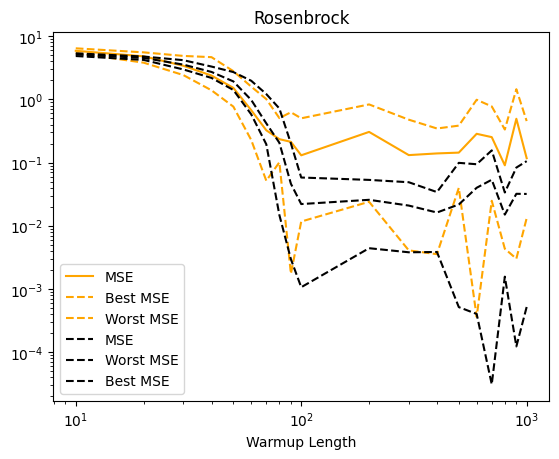

In [25]:
ax = simulation_df.plot(
    x="Warmup Length",
    y="MSE",
    logx=True,
    logy=True,
    title="Rosenbrock",
    linestyle="-",
    color="orange"
)

simulation_df.plot(
    x="Warmup Length",
    y="Best MSE",
    logx=True,
    logy=True,
    linestyle="--",
    color="orange",
    ax=ax,
)
simulation_df.plot(
    x="Warmup Length",
    y="Worst MSE",
    logx=True,
    logy=True,
    linestyle="--",
    color="orange",
    ax=ax,
)
simulation_naive_df.plot(
    x="Warmup Length",
    y="MSE",
    logx=True,
    logy=True,
    linestyle="--",
    color="black",
    ax=ax,
)
simulation_naive_df.plot(
    x="Warmup Length",
    y="Worst MSE",
    logx=True,
    logy=True,
    linestyle="--",
    color="black",
    ax=ax,
)
simulation_naive_df.plot(
    x="Warmup Length",
    y="Best MSE",
    logx=True,
    logy=True,
    linestyle="--",
    color="black",
    ax=ax,
)

In [19]:
simulation_df.head()

,Warmup Length,MSE,Nested R Hat,Best MSE,Worst MSE
0,10,5.894411,[1.0400344],5.438864,6.449607
1,20,4.819632,[1.0335087],3.822550,5.567114
2,30,3.417166,[1.0304967],2.432395,4.889427
3,40,2.389784,[1.0358901],1.396198,4.672868
4,50,1.524986,[1.0312886],0.770383,2.805651


How did he made the MSE so low?????

<Axes: title={'center': 'Rosenbrock'}, xlabel='Nested R Hat - 1', ylabel='MSE'>

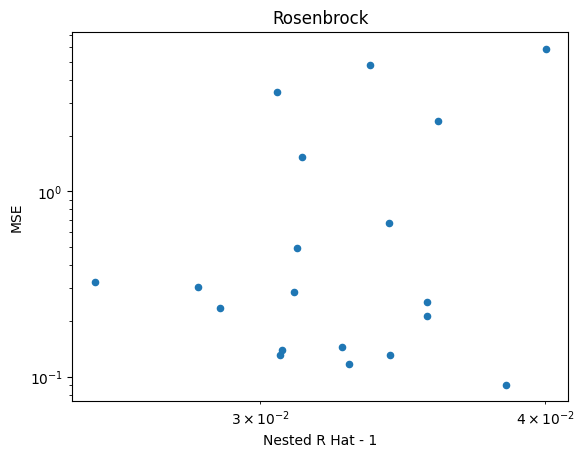

In [26]:
simulation_df["Nested R Hat - 1"] = simulation_df["Nested R Hat"] - 1

simulation_df.plot.scatter(
    x="Nested R Hat - 1",
    y="MSE",
    logx=True,
    logy=True,
    title="Rosenbrock"
)

Next step:  
R hat change to number of parameters returned  

In [27]:
del simulation_df
del simulation_naive_df